In [20]:
from typing import Annotated

from langchain_ollama import ChatOllama

In [55]:
import subprocess
process = subprocess.Popen("ollama serve", shell=True)

2025/04/30 20:48:10 routes.go:1232: INFO server config env="map[CUDA_VISIBLE_DEVICES: GPU_DEVICE_ORDINAL: HIP_VISIBLE_DEVICES: HSA_OVERRIDE_GFX_VERSION: HTTPS_PROXY: HTTP_PROXY: NO_PROXY: OLLAMA_CONTEXT_LENGTH:2048 OLLAMA_DEBUG:false OLLAMA_FLASH_ATTENTION:false OLLAMA_GPU_OVERHEAD:0 OLLAMA_HOST:http://127.0.0.1:11434 OLLAMA_INTEL_GPU:false OLLAMA_KEEP_ALIVE:5m0s OLLAMA_KV_CACHE_TYPE: OLLAMA_LLM_LIBRARY: OLLAMA_LOAD_TIMEOUT:5m0s OLLAMA_MAX_LOADED_MODELS:0 OLLAMA_MAX_QUEUE:512 OLLAMA_MODELS:/root/.ollama/models OLLAMA_MULTIUSER_CACHE:false OLLAMA_NEW_ENGINE:false OLLAMA_NOHISTORY:false OLLAMA_NOPRUNE:false OLLAMA_NUM_PARALLEL:0 OLLAMA_ORIGINS:[http://localhost https://localhost http://localhost:* https://localhost:* http://127.0.0.1 https://127.0.0.1 http://127.0.0.1:* https://127.0.0.1:* http://0.0.0.0 https://0.0.0.0 http://0.0.0.0:* https://0.0.0.0:* app://* file://* tauri://* vscode-webview://* vscode-file://*] OLLAMA_SCHED_SPREAD:false ROCR_VISIBLE_DEVICES: http_proxy: https_proxy:

In [56]:
!ollama list

[GIN] 2025/04/30 - 20:48:14 | 200 |      52.008µs |       127.0.0.1 | HEAD     "/"
[GIN] 2025/04/30 - 20:48:14 | 200 |     596.971µs |       127.0.0.1 | GET      "/api/tags"
NAME        ID              SIZE      MODIFIED       
qwen3:8b    e4b5fd7f8af0    5.2 GB    34 minutes ago    


In [61]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
TAVILY_API_KEY = user_secrets.get_secret("TAVILY_API_KEY")


api_wrapper = TavilySearchAPIWrapper(tavily_api_key=TAVILY_API_KEY)
tavily_tool = TavilySearchResults(api_wrapper=api_wrapper)

In [62]:
from langchain_tavily import TavilySearch



tool = TavilySearch(max_results=2)
tools = [tool]
tool.invoke("What's a 'node' in LangGraph?")

{'query': "What's a 'node' in LangGraph?",
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'title': "Introduction to LangGraph: A Beginner's Guide - Medium",
   'url': 'https://medium.com/@cplog/introduction-to-langgraph-a-beginners-guide-14f9be027141',
   'content': 'Stateful Graph: LangGraph revolves around the concept of a stateful graph, where each node in the graph represents a step in your computation, and the graph maintains a state that is passed around and updated as the computation progresses. LangGraph supports conditional edges, allowing you to dynamically determine the next node to execute based on the current state of the graph. We define nodes for classifying the input, handling greetings, and handling search queries. def classify_input_node(state): LangGraph is a versatile tool for building complex, stateful applications with LLMs. By understanding its core concepts and working through simple examples, beginners can start to leverage its powe

In [26]:
from typing import Annotated

from langchain_ollama import ChatOllama

In [27]:
model = ChatOllama(model="qwen3:8b")

result = model.invoke("hello qwen!!")

time=2025-04-30T20:14:56.605Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32
time=2025-04-30T20:14:56.732Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32
time=2025-04-30T20:14:56.754Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32
time=2025-04-30T20:14:56.755Z level=WARN source=ggml.go:152 msg="key not found" key=qwen3.vision.block_count default=0
time=2025-04-30T20:14:56.756Z level=INFO source=sched.go:722 msg="new model will fit in available VRAM in single GPU, loading" model=/root/.ollama/models/blobs/sha256-a3de86cd1c132c822487ededd47a324c50491393e6565cd14bafa40d0b8e686f gpu=GPU-9b524957-1626-248b-3674-3dc491a0dec9 parallel=4 available=16790978560 required="7.0 GiB"
time=2025-04-30T20:14:56.858Z level=INFO source=server.go:105 msg="system memory" total="31.4 GiB" free="29.9 GiB" free_swap="0 B"
time=2025-04-30T20:14:56.858Z level=WARN source=ggml.go:152 msg="key not found" ke

[GIN] 2025/04/30 - 20:15:03 | 200 |  6.510918741s |       127.0.0.1 | POST     "/api/chat"


In [28]:
print(result)

content='<think>\nOkay, the user said "hello qwen!!" So they\'re greeting me. I should respond in a friendly and enthusiastic way. Let me make sure to acknowledge their greeting and offer assistance. Maybe add some emojis to keep it light and approachable. I should also check if they need help with anything specific. Let me keep the tone positive and open.\n</think>\n\nHello! 😊 How can I assist you today? I\'m here to help with any questions or tasks you might have!' additional_kwargs={} response_metadata={'model': 'qwen3:8b', 'created_at': '2025-04-30T20:15:03.095350442Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6510826136, 'load_duration': 3329848025, 'prompt_eval_count': 12, 'prompt_eval_duration': 281118266, 'eval_count': 102, 'eval_duration': 2898591382, 'model_name': 'qwen3:8b'} id='run-e44abb62-a511-4e49-be4a-216549b15e0d-0' usage_metadata={'input_tokens': 12, 'output_tokens': 102, 'total_tokens': 114}


In [64]:
from typing import Annotated

from langchain_ollama import ChatOllama
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL
from langchain_community.utilities.tavily_search import TavilySearchAPIWrapper

api_wrapper = TavilySearchAPIWrapper(tavily_api_key=TAVILY_API_KEY)
tavily_tool = TavilySearchResults(api_wrapper=api_wrapper)

tavily_tool = TavilySearchResults(max_results = 3)
repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "Python code to execute to generate your chart."]
    ):
  """Use this to execute python code and do math. If you want to see the output of a value,
  you should print it out with 'print(...)'. This is visible to the user."""
  try:
    result = repl.run(code)
  except BaseException as e:
    return f"Failed to execute. Error: {repr(e)}"
  result_str = f"Successfully exectued:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
  return result_str

# Create Agent Supervisor
LLM with structured output & choose next worker node OR finish processing

In [43]:
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import MessagesState, END
from langgraph.types import Command

members = ["researcher", "coder"]

options = members + ["FINISH"]

system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    f" following workers: {members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)

class Router(TypedDict):
  """Worker to route to next node. If no workers needed, route to FINISH."""
  next: Literal['researcher', 'coder', 'FINISH']

class State(MessagesState):
  next: str

llm_router = ChatOllama(model="qwen3:8b")

def supervisor_node(state: State) -> Command[Literal[Literal['researcher', 'coder', "__end__"]]]:
  messages = [
      {"role": "system", "content": system_prompt},
  ] + state["messages"]
  response = llm_router.with_structured_output(Router).invoke(messages)
  goto = response["next"]
  if goto == "FINISH":
    goto = END

  return Command(goto=goto, update={"next": goto})


# Constructing Graph

---

In [49]:
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import HumanMessage

llm_researcher = llm_router
#coder_llm = ChatOllama(model="qwen2.5-coder")
coder_llm = llm_router

research_agent = create_react_agent(
    llm_researcher, tools=[tavily_tool], prompt="You are a researcher, DO NOT do any math."
)

def research_node(state: State) -> Command[Literal["supervisor"]]:
  result = research_agent.invoke(state)
  return Command(
      update={
          "messages": [
              HumanMessage(content=result["messages"][-1].content, name="researcher")
          ]
      },
      goto="supervisor",
  )

code_agent = create_react_agent(
    coder_llm, tools=[python_repl_tool]
)


def code_node(state: State) -> Command[Literal["supervisor"]]:
  result = code_agent.invoke(state)
  return Command(
      update={
          "messages": [
              HumanMessage(content=result["messages"][-1].content, name="coder")
          ]
      },
      goto="supervisor",
  )


builder = StateGraph(State)
builder.add_node("supervisor", supervisor_node)
builder.add_node("researcher", research_node)
builder.add_node("coder", code_node)
builder.add_edge(START, "supervisor")
#builder.add_edge("supervisor", END)

graph = builder.compile()


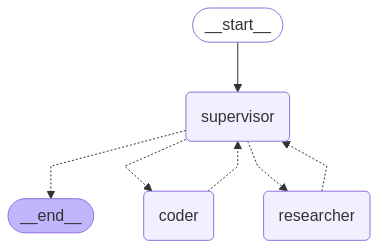

In [45]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [46]:
for s in graph.stream(
    {"messages": [("user", "What is square root of 42?")]}, subgraphs=True):
  print (s)
  print("------")

time=2025-04-30T20:37:42.654Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32
time=2025-04-30T20:37:42.783Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32
time=2025-04-30T20:37:42.803Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32
time=2025-04-30T20:37:42.804Z level=WARN source=ggml.go:152 msg="key not found" key=qwen3.vision.block_count default=0
time=2025-04-30T20:37:42.805Z level=INFO source=sched.go:722 msg="new model will fit in available VRAM in single GPU, loading" model=/root/.ollama/models/blobs/sha256-a3de86cd1c132c822487ededd47a324c50491393e6565cd14bafa40d0b8e686f gpu=GPU-9b524957-1626-248b-3674-3dc491a0dec9 parallel=4 available=16790978560 required="7.0 GiB"
time=2025-04-30T20:37:42.903Z level=INFO source=server.go:105 msg="system memory" total="31.4 GiB" free="29.8 GiB" free_swap="0 B"
time=2025-04-30T20:37:42.903Z level=WARN source=ggml.go:152 msg="key not found" ke

[GIN] 2025/04/30 - 20:37:46 | 200 |  3.625907979s |       127.0.0.1 | POST     "/api/chat"
((), {'supervisor': {'next': 'researcher'}})
------


time=2025-04-30T20:37:46.282Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32


[GIN] 2025/04/30 - 20:38:09 | 200 | 22.846349628s |       127.0.0.1 | POST     "/api/chat"
(('researcher:4ab29739-7808-3190-5e49-b223adec8c1b',), {'agent': {'messages': [AIMessage(content="<think>\nOkay, the user is asking for the square root of 42. Let me think. I know that the square root of a number is a value that, when multiplied by itself, gives the original number. So, I need to find a number that when squared equals 42.\n\nFirst, I recall that 6 squared is 36 and 7 squared is 49. Since 42 is between 36 and 49, the square root of 42 must be between 6 and 7. But the user probably wants an exact value or a simplified radical form. \n\nWait, 42 can be factored into 6 * 7, which are both prime numbers. Since there are no perfect square factors other than 1, the square root of 42 can't be simplified further. So the exact form is √42, and the approximate decimal value is around 6.4807. \n\nBut the user might not need the approximate value. They might just want the exact value. However

time=2025-04-30T20:38:09.134Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32


((), {'supervisor': {'next': '__end__'}})
------
[GIN] 2025/04/30 - 20:38:11 | 200 |  2.198042449s |       127.0.0.1 | POST     "/api/chat"


In [58]:
inps = {
    "role": "user",
    "content": "What is 2+4"
}

graph.invoke({"messages":[inps]}, subgraphs=True)

time=2025-04-30T20:49:17.756Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32


[GIN] 2025/04/30 - 20:49:18 | 200 |  420.714265ms |       127.0.0.1 | POST     "/api/chat"


time=2025-04-30T20:49:18.184Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32


[GIN] 2025/04/30 - 20:49:22 | 200 |  4.216133222s |       127.0.0.1 | POST     "/api/chat"


time=2025-04-30T20:49:22.402Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32


[GIN] 2025/04/30 - 20:49:23 | 200 |  943.597189ms |       127.0.0.1 | POST     "/api/chat"


((),
 {'messages': [HumanMessage(content='What is 2+4', additional_kwargs={}, response_metadata={}, id='1632da32-8b1b-480c-9bf0-124609b5e5ea'),
   HumanMessage(content='<think>\nOkay, the user is asking "What is 2+4". Let me think. This is a simple arithmetic problem. Adding 2 and 4 together. Let me check if I need to use any tools here. The tools provided are for search queries, but this is a basic math question. Since 2+4 is straightforward, the answer is 6. I don\'t need to call the tavily search function here because there\'s no need for external information. Just a direct calculation.\n</think>\n\nThe result of 2 + 4 is 6.', additional_kwargs={}, response_metadata={}, name='researcher', id='56b419de-7111-48a4-9e45-f5c69a8cf757')],
  'next': '__end__'})

In [65]:
inps = {
    "role": "user",
    "content": "Who won today in ipl 2025"
}

graph.invoke({"messages":[inps]}, subgraphs=True)

time=2025-04-30T21:20:00.329Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32
time=2025-04-30T21:20:00.456Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32
time=2025-04-30T21:20:00.477Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32
time=2025-04-30T21:20:00.479Z level=WARN source=ggml.go:152 msg="key not found" key=qwen3.vision.block_count default=0
time=2025-04-30T21:20:00.479Z level=INFO source=sched.go:722 msg="new model will fit in available VRAM in single GPU, loading" model=/root/.ollama/models/blobs/sha256-a3de86cd1c132c822487ededd47a324c50491393e6565cd14bafa40d0b8e686f gpu=GPU-9b524957-1626-248b-3674-3dc491a0dec9 parallel=4 available=16790978560 required="7.0 GiB"
time=2025-04-30T21:20:00.582Z level=INFO source=server.go:105 msg="system memory" total="31.4 GiB" free="29.8 GiB" free_swap="0 B"
time=2025-04-30T21:20:00.582Z level=WARN source=ggml.go:152 msg="key not found" ke

[GIN] 2025/04/30 - 21:20:04 | 200 |  3.727045627s |       127.0.0.1 | POST     "/api/chat"


time=2025-04-30T21:20:04.060Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32


[GIN] 2025/04/30 - 21:20:11 | 200 |  7.076276718s |       127.0.0.1 | POST     "/api/chat"


time=2025-04-30T21:20:13.609Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32


[GIN] 2025/04/30 - 21:20:26 | 200 | 12.737858867s |       127.0.0.1 | POST     "/api/chat"


time=2025-04-30T21:20:26.354Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32


[GIN] 2025/04/30 - 21:20:27 | 200 |  1.451099221s |       127.0.0.1 | POST     "/api/chat"


((),
 {'messages': [HumanMessage(content='Who won today in ipl 2025', additional_kwargs={}, response_metadata={}, id='058696cd-917e-406b-bc8e-201259adff44'),
   HumanMessage(content="<think>\nOkay, the user asked who won today's match in IPL 2025. Let me check the tool response.\n\nLooking at the first result from ESPNcricinfo, the 49th Match on April 30, 2025, shows PBKS won by 4 wickets. The content mentions PBKS vs CSK, and the result is PBKS winning. The score here is 0.87, which seems high, but maybe it's a confidence score. The second result is about a match on March 26th where KKR scored 153-2, but the result isn't clear. The third result mentions RCB winning on March 23rd. However, the user is asking about today's match. Since the current date isn't provided, but the latest match mentioned is April 30th, which is the most recent. So the answer should be PBKS won against CSK. I need to confirm if April 30th is today's date, but since the user is asking in 2025, maybe the data is

In [60]:
for s in graph.stream(
    {
        "messages": [
            (
                "user",
                "Find the latest GDP of New York and California, then calculate the average. Output only 'NY GDP:', 'CA GDP:', and the final avg",
            )
        ]
    },
    subgraphs=True,
):
    print(s)
    print("----")

time=2025-04-30T20:59:44.780Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32
time=2025-04-30T20:59:44.905Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32
time=2025-04-30T20:59:44.926Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32
time=2025-04-30T20:59:44.927Z level=WARN source=ggml.go:152 msg="key not found" key=qwen3.vision.block_count default=0
time=2025-04-30T20:59:44.928Z level=INFO source=sched.go:722 msg="new model will fit in available VRAM in single GPU, loading" model=/root/.ollama/models/blobs/sha256-a3de86cd1c132c822487ededd47a324c50491393e6565cd14bafa40d0b8e686f gpu=GPU-9b524957-1626-248b-3674-3dc491a0dec9 parallel=4 available=16790978560 required="7.0 GiB"
time=2025-04-30T20:59:45.028Z level=INFO source=server.go:105 msg="system memory" total="31.4 GiB" free="29.7 GiB" free_swap="0 B"
time=2025-04-30T20:59:45.028Z level=WARN source=ggml.go:152 msg="key not found" ke

((), {'supervisor': {'next': 'researcher'}})[GIN] 2025/04/30 - 20:59:48 | 200 |  3.600234043s |       127.0.0.1 | POST     "/api/chat"

----


time=2025-04-30T20:59:48.385Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32


[GIN] 2025/04/30 - 20:59:55 | 200 |   7.11262348s |       127.0.0.1 | POST     "/api/chat"
(('researcher:8cd4bbe7-de74-d1b1-51ac-4a7564c09658',), {'agent': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:8b', 'created_at': '2025-04-30T20:59:55.47715987Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7112505356, 'load_duration': 23014827, 'prompt_eval_count': 211, 'prompt_eval_duration': 186195264, 'eval_count': 209, 'eval_duration': 6897403185, 'model_name': 'qwen3:8b'}, id='run-e8437298-b25d-4cd2-bd4a-6ffddaa9f2d9-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'latest GDP of New York and California 2023'}, 'id': '7c2c03a1-9680-4b71-88d8-fc2e2f58601e', 'type': 'tool_call'}], usage_metadata={'input_tokens': 211, 'output_tokens': 209, 'total_tokens': 420})]}})
----
(('researcher:8cd4bbe7-de74-d1b1-51ac-4a7564c09658',), {'tools': {'messages': [ToolMessage(content='[{"title": "US States comparison: California 

time=2025-04-30T20:59:59.324Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32


[GIN] 2025/04/30 - 21:01:03 | 200 |          1m3s |       127.0.0.1 | POST     "/api/chat"
(('researcher:8cd4bbe7-de74-d1b1-51ac-4a7564c09658',), {'agent': {'messages': [AIMessage(content='<think>\nOkay, let\'s tackle this step by step. The user wants the latest GDP of New York and California for 2023, then the average.\n\nFirst, I need to find the GDP figures. Looking at the search results, there are a few sources. The first one mentions California\'s GDP as $3,870,379M in 2023. Wait, that\'s in millions, so actually $3.870379 trillion. But the second source from Jagran Josh says in 2024, California\'s GDP is $41,03,124 (which might be a formatting issue, maybe $41.03 trillion?), but the 2023 figure there is $32,48,657 (possibly $32.48657 trillion). However, the first source\'s number seems way higher. Wait, maybe the first source is in billions? Let me check again.\n\nWait, the first result says "Annual GDP [+], 2023, $3,870,379M". That\'s 3.870379 trillion. But the second source fro

time=2025-04-30T21:01:03.143Z level=WARN source=ggml.go:152 msg="key not found" key=general.alignment default=32


[GIN] 2025/04/30 - 21:01:07 | 200 |  4.653415196s |       127.0.0.1 | POST     "/api/chat"
((), {'supervisor': {'next': '__end__'}})
----
